In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# Distribution embedding

In [2]:
def norm_binning(_data, _nbins):
    
    data_interval = max(_data) - min(_data)
    bin_length = float(data_interval)/float(_nbins)
    
    binned_data = {}
    for b in range(_nbins):
        bin_min_val = min(_data) + bin_length * b
        bin_max_val = min(_data) + bin_length * (b+1)
        
        bin_counts = sum(1 for x in _data if bin_min_val <= x < bin_max_val)
        if b == _nbins-1: 
            bin_counts += sum(1 for x in _data if x == bin_max_val)

        binned_data.update({format(int(b), f'0{int(np.log2(_nbins))}b') : bin_counts})
    return binned_data

def dist(_size):
    return np.random.normal(loc = 1.0, scale = 1.0, size = _size)

def sample_dist(_size, _nbins):
    _sample = dist(_size)
    return norm_binning(_sample, _nbins)    

(array([  3.,  27.,  88., 265., 303., 209.,  89.,  16.]),
 array([-2.55679568, -1.74925457, -0.94171345, -0.13417233,  0.67336878,
         1.4809099 ,  2.28845101,  3.09599213,  3.90353324]),
 <BarContainer object of 8 artists>)

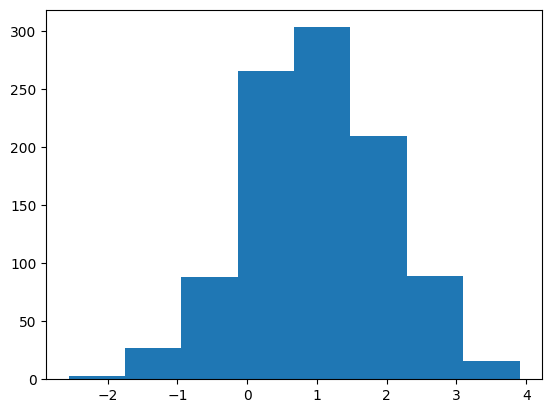

In [3]:
nbins = 8
plt.hist(dist(1000), bins = nbins)

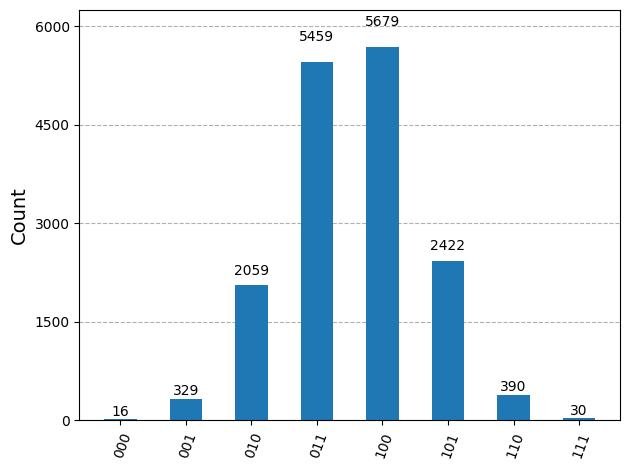

In [4]:
plot_histogram(sample_dist(2**14, nbins))

# QGAN evaluation

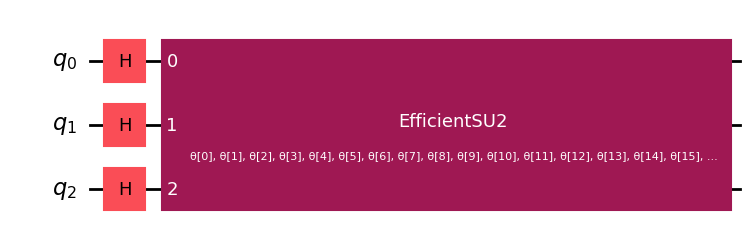

In [5]:
from qiskit.circuit.library import efficient_su2
num_qubits = int(np.log2(nbins))

qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
esu2_gate = efficient_su2(num_qubits = num_qubits, reps = 6).to_gate()
qc.append(esu2_gate, range(num_qubits))
    
qc.draw('mpl')

In [6]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, InputLayer


discriminator = Sequential([InputLayer(input_shape=(nbins,)),
                            Dense(128, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(128, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(1, activation='sigmoid')
                            ])
discriminator.summary()

2026-03-05 09:04:17.289548: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 09:04:17.303112: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772697857.320301   13878 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772697857.325822   13878 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772697857.338750   13878 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from qgan import QGAN

In [8]:
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [9]:
epochs = 1000
model.fit(epochs = epochs, opt = 'SPSA', maxiter = epochs, a = 0.05)

Training started


100%|██████████| 1000/1000 [04:33<00:00,  3.66it/s]

Training completed


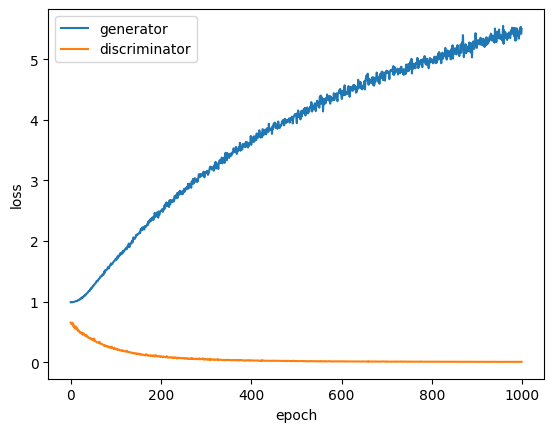

In [10]:
plt.plot(range(len(model.generator_losses)), model.generator_losses, label = 'generator')
plt.plot(range(epochs), model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

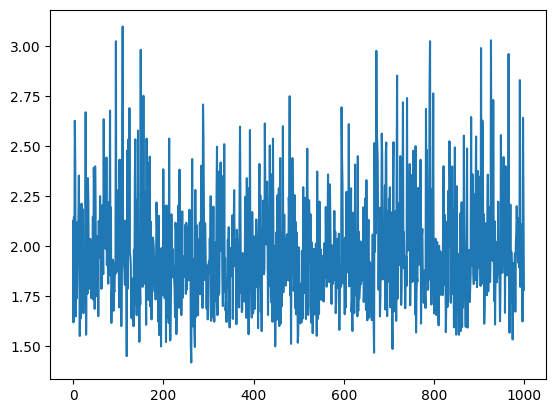

In [11]:
plt.plot(range(len(model.metrics['kullback_leibler'])), model.metrics['kullback_leibler'])

In [12]:
nsamples = 2**14
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)

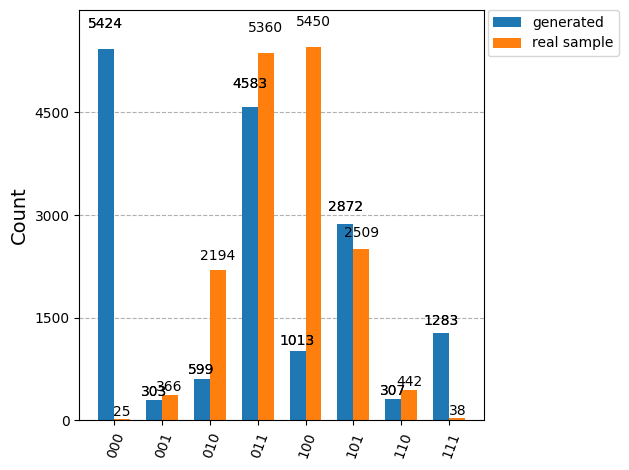

In [13]:
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])

# Real amplitudes

/tmp/ipykernel_13878/3968159094.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ra_gate = TwoLocal(num_qubits,


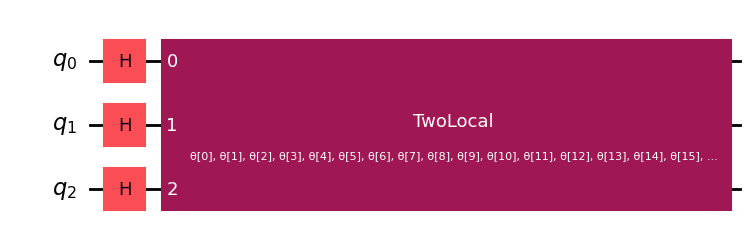

In [14]:
from qiskit.circuit.library import TwoLocal
num_qubits = int(np.log2(nbins))

qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
ra_gate = TwoLocal(num_qubits, 
                     rotation_blocks=['ry'], 
                     entanglement_blocks='cz', 
                     entanglement='full', 
                     reps = 6).to_gate()
qc.append(ra_gate, range(num_qubits))
    
qc.draw('mpl')

In [15]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, InputLayer


discriminator = Sequential([InputLayer(input_shape=(nbins,)),
                            Dense(16, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(16, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(1, activation='sigmoid')
                            ])
discriminator.summary()

/usr/local/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433 (1.69 KB)

 Trainable params: 433 (1.69 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [17]:
epochs = 1000
model.fit(epochs = epochs, opt = 'SPSA')

Training started


100%|██████████| 1000/1000 [04:49<00:00,  3.46it/s]

Training completed


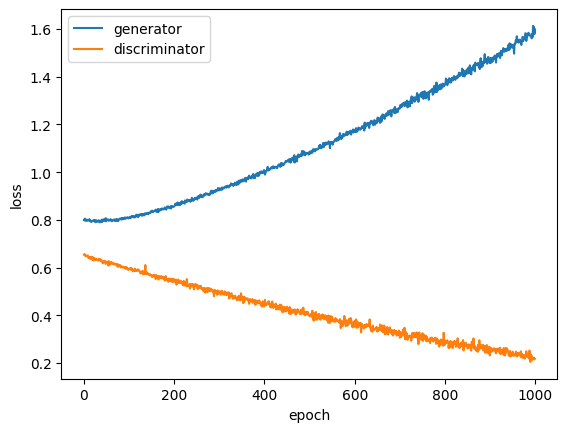

In [18]:
plt.plot(range(epochs), model.generator_losses, label = 'generator')
plt.plot(range(epochs), model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

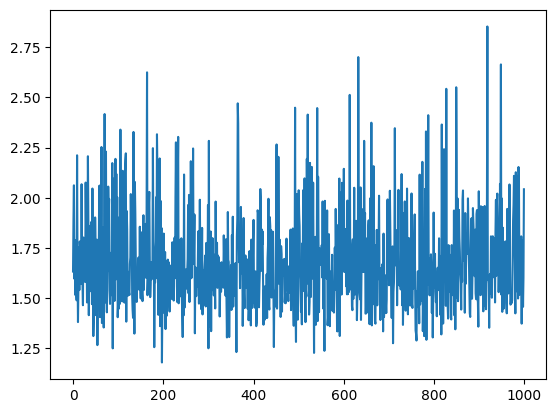

In [19]:
plt.plot(range(epochs), model.metrics['kullback_leibler'])